In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots
import numpy as np

In [2]:
plt.style.use(['science', 'notebook', 'grid'])

In [3]:
ball_df = pd.read_csv("../data/processed/ball_by_ball.csv") 
match_df = pd.read_csv("../data/processed/match_by_match.csv")

In [4]:
print("Shape of DataFrame:", ball_df.shape)
print("\nColumns:\n", ball_df.columns)

Shape of DataFrame: (295732, 11)

Columns:
 Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batsman', 'bowler', 'non_striker', 'runs_batsman', 'runs_total'],
      dtype='str')


In [5]:
print("Shape of DataFrame:", match_df.shape)
print("\nColumns:\n", match_df.columns)

Shape of DataFrame: (1243, 13)

Columns:
 Index(['match_id', 'date', 'venue', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'winner', 'result', 'team1_score', 'team2_score',
       'team1_players', 'team2_players'],
      dtype='str')


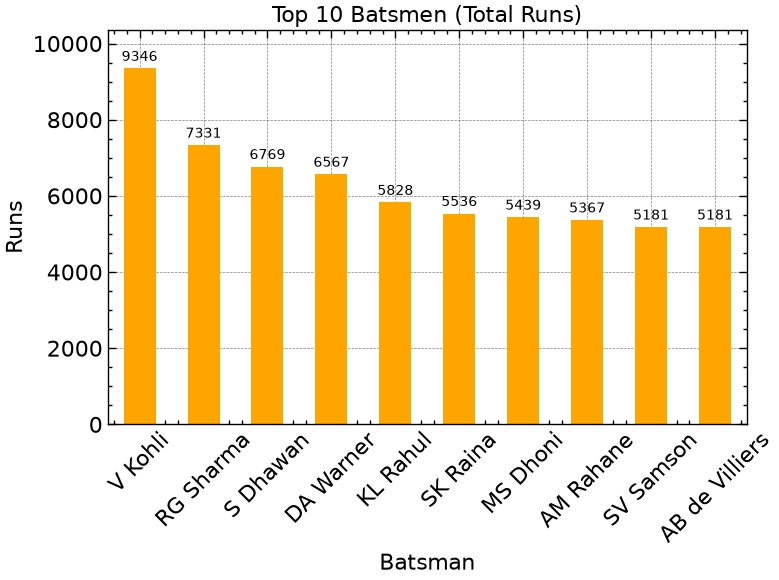

In [6]:
ball_df = ball_df[ball_df['batsman'].notna() & ball_df['runs_batsman'].notna()]

ball_df['runs_batsman'] = pd.to_numeric(ball_df['runs_batsman'], errors='coerce')

top_batsmen = (
    ball_df.groupby('batsman')['runs_batsman']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

if not top_batsmen.empty:
    ax = top_batsmen.plot(
        kind='bar',
        title='Top 10 Batsmen (Total Runs)',
        ylabel='Runs',
        xlabel='Batsman',
        color='orange'
    )

    ax.bar_label(ax.containers[0], fmt='%d', padding=3)

    plt.xticks(rotation=45)
    ax.set_ylim(0, top_batsmen.max() + 1000)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No valid data for batsman runs!")

In [7]:
# valid_wickets = ball_df[ball_df['player_dismissed'].notna() & ball_df['kind'].notna()]

# bowler_wicket_kinds = ['bowled', 'caught', 'lbw', 'stumped', 'caught and bowled', 'hit wicket']

# valid_wickets = valid_wickets[valid_wickets['kind'].isin(bowler_wicket_kinds)]

# top_bowlers = valid_wickets['bowler'].value_counts().head(10)

# if not top_bowlers.empty:
#     top_bowlers.plot(kind='bar', title='Top 10 Wicket-Takers', ylabel='Wickets', xlabel='Bowler', color='purple')
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()
# else:
#     print("⚠️ No valid data for bowler wickets!")

#     top_bowlers.plot(kind='bar', title='Top 10 Wicket-Takers', ylabel='Wickets', xlabel='Bowler', color='purple')
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()

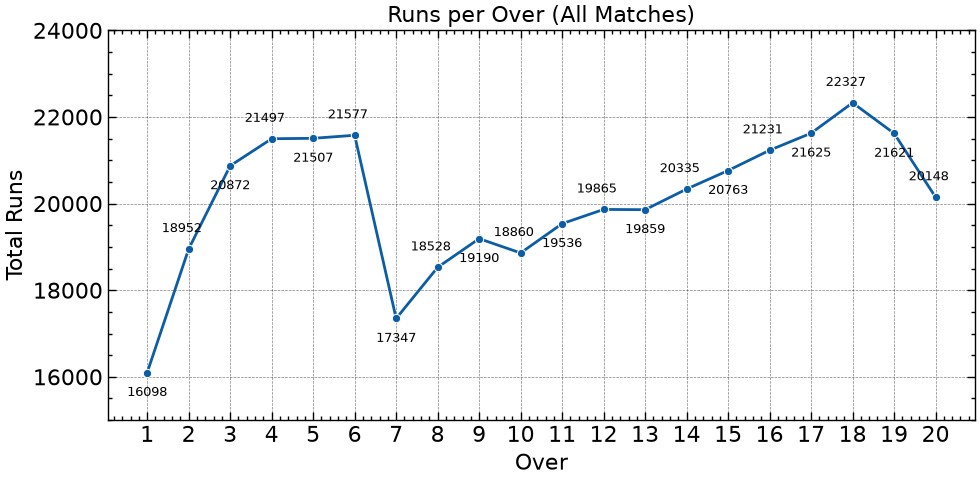

In [8]:
runs_per_over = ball_df.groupby('over')['runs_total'].sum()

plt.figure(figsize=(10, 5))

ax = sns.lineplot(
    x=runs_per_over.index,
    y=runs_per_over.values,
    marker='o'
)

for x, y in zip(runs_per_over.index, runs_per_over.values):
    if (x + 1) % 2 == 0:  
        xytext = (-5, 10)
        va = 'bottom'
    else:                  
        xytext = (0, -10)
        va = 'top'

    ax.annotate(
        f'{int(y)}',
        (x, y),
        textcoords="offset points",
        xytext=xytext,
        ha='center',
        va=va,
        fontsize=9
    )

plt.title('Runs per Over (All Matches)')
plt.xlabel('Over')
plt.ylabel('Total Runs')

plt.xticks(ticks=range(0, 20), labels=[str(i) for i in range(1, 21)])
plt.ylim(15_000, 24_000)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

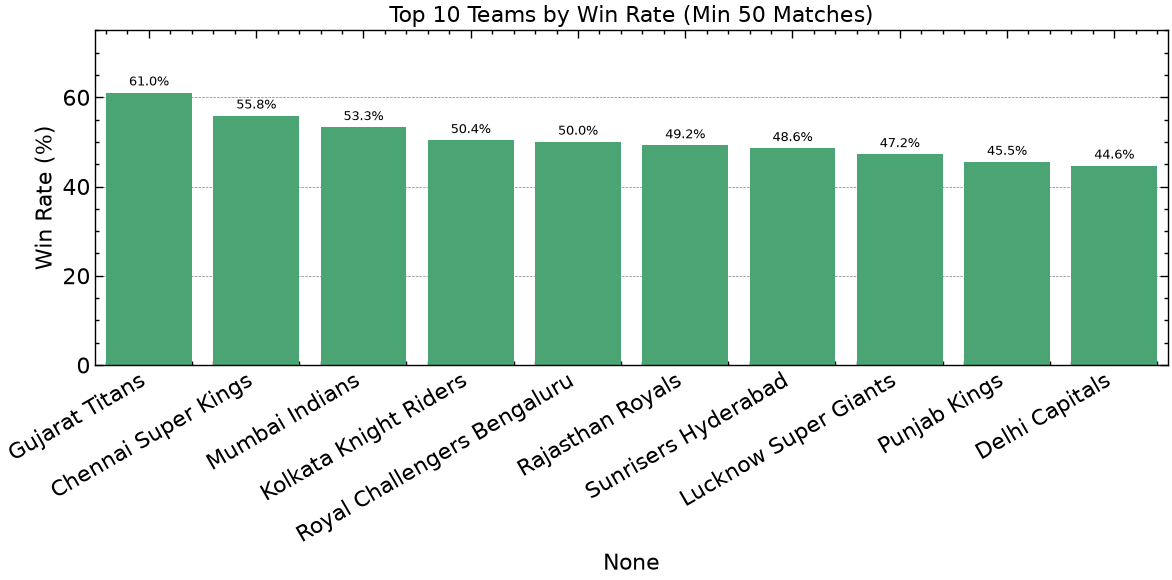

In [9]:
matches_played = pd.concat([match_df['team1'], match_df['team2']]).value_counts()

matches_won = match_df['winner'].value_counts()

win_rate_df = pd.DataFrame({
    'matches_played': matches_played,
    'matches_won': matches_won
})
win_rate_df.fillna(0, inplace=True)
win_rate_df['win_rate'] = (win_rate_df['matches_won'] / win_rate_df['matches_played']) * 100

win_rate_df_filtered = win_rate_df[win_rate_df['matches_played'] >= 50]

top_win_rate = win_rate_df_filtered.sort_values('win_rate', ascending=False).head(10)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=top_win_rate.index,
    y=top_win_rate['win_rate'],
    color='mediumseagreen'
)

ax.bar_label(
    ax.containers[0],
    fmt='%.1f%%',
    padding=3,
    fontsize=9
)

plt.title("Top 10 Teams by Win Rate (Min 50 Matches)")
plt.ylabel("Win Rate (%)")
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 75)
plt.tight_layout()
plt.show()

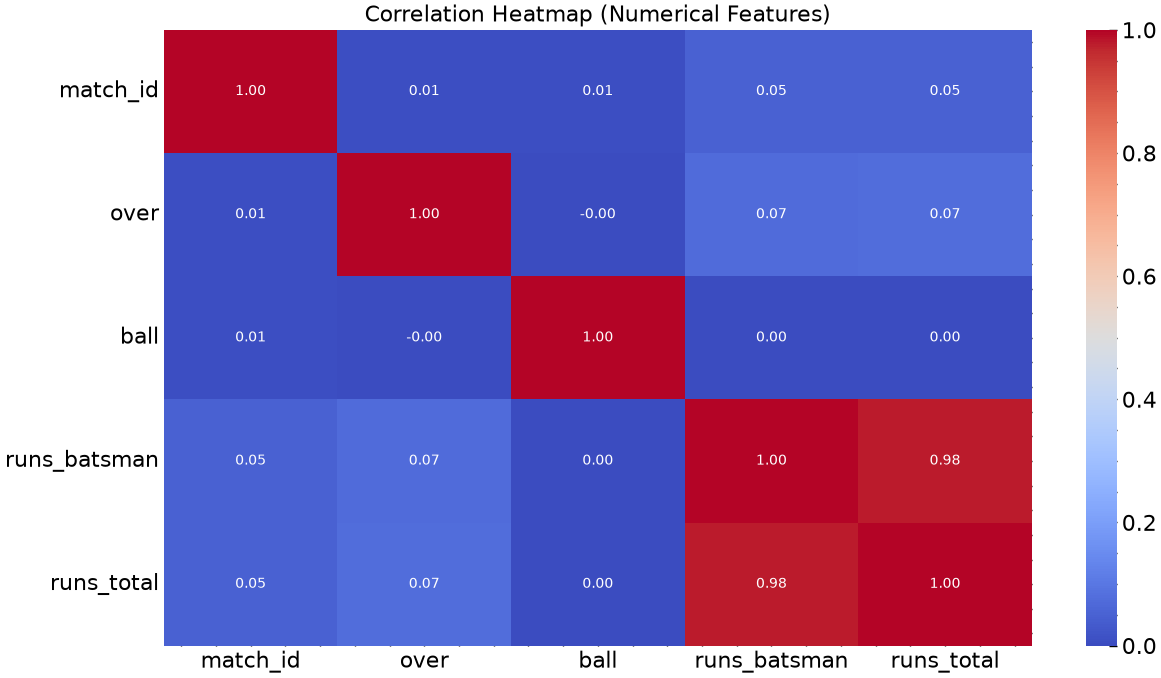

In [10]:
plt.figure(figsize=(14, 8))
sns.heatmap(ball_df.select_dtypes(include='number').corr(), cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

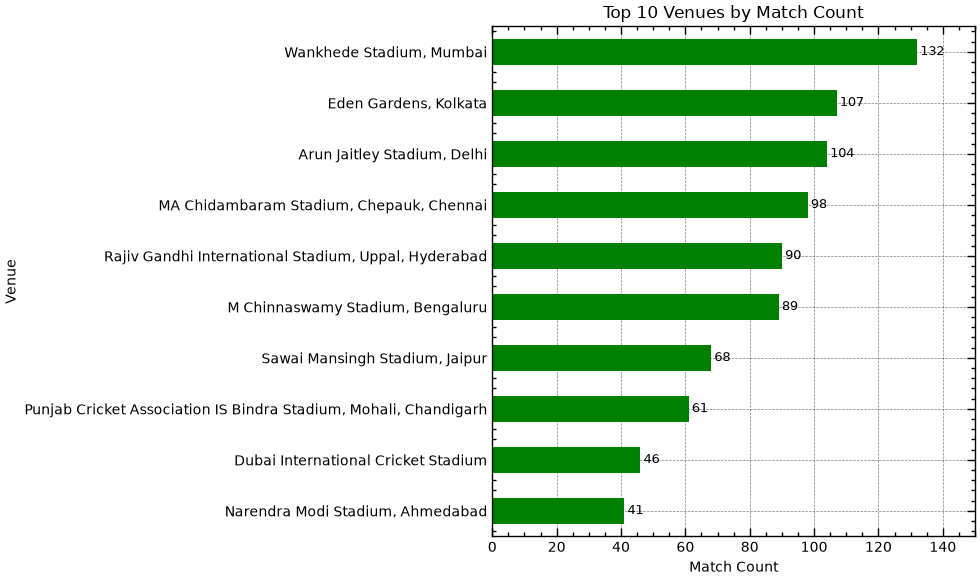

In [46]:
top_venues = match_df['venue'].value_counts().head(10)

plt.figure(figsize=(10, 6))

ax = top_venues.plot(
    kind='barh',
    color='green',
    title='Top 10 Venues by Match Count'
)

for bar in ax.patches:
    width = bar.get_width()
    ax.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f'{int(width)}',
        va='center',
        fontsize=9
    )

ax.set_xlabel("Match Count", fontsize=10)
ax.set_ylabel("Venue", fontsize=10)
ax.set_title("Top 10 Venues by Match Count", fontsize=12)

ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)

plt.xlim(0, 150)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

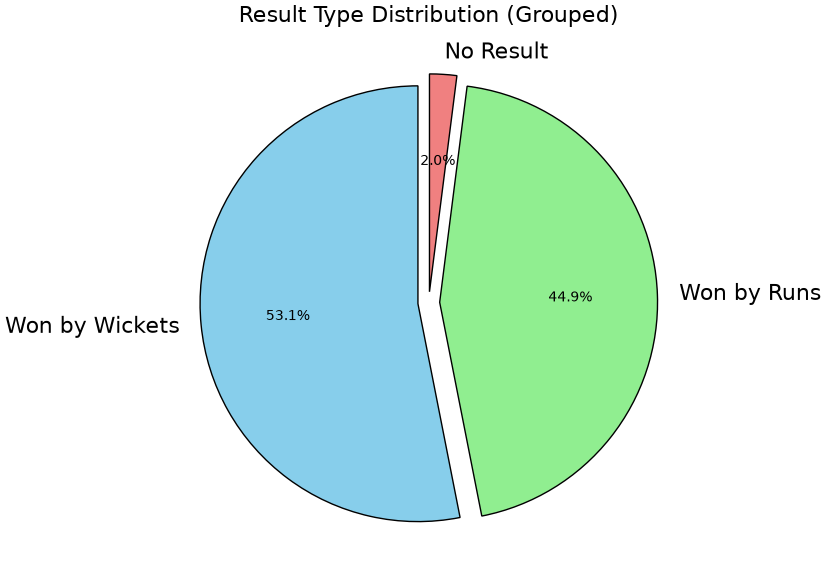

In [12]:
match_df['result'] = match_df['result'].fillna('no result')

def simplify_result(result):
    if 'wickets' in result:
        return 'Won by Wickets'
    elif 'runs' in result:
        return 'Won by Runs'
    elif result == 'no result':
        return 'No Result'
    else:
        return 'Other'

match_df['result_category'] = match_df['result'].apply(simplify_result)

match_df['result_category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.05]*3,
    colors=['skyblue', 'lightgreen', 'lightcoral'],
    wedgeprops={'linewidth': 1, 'edgecolor': 'black'}
)
plt.title('Result Type Distribution (Grouped)')
plt.ylabel('')
plt.tight_layout()
plt.show()


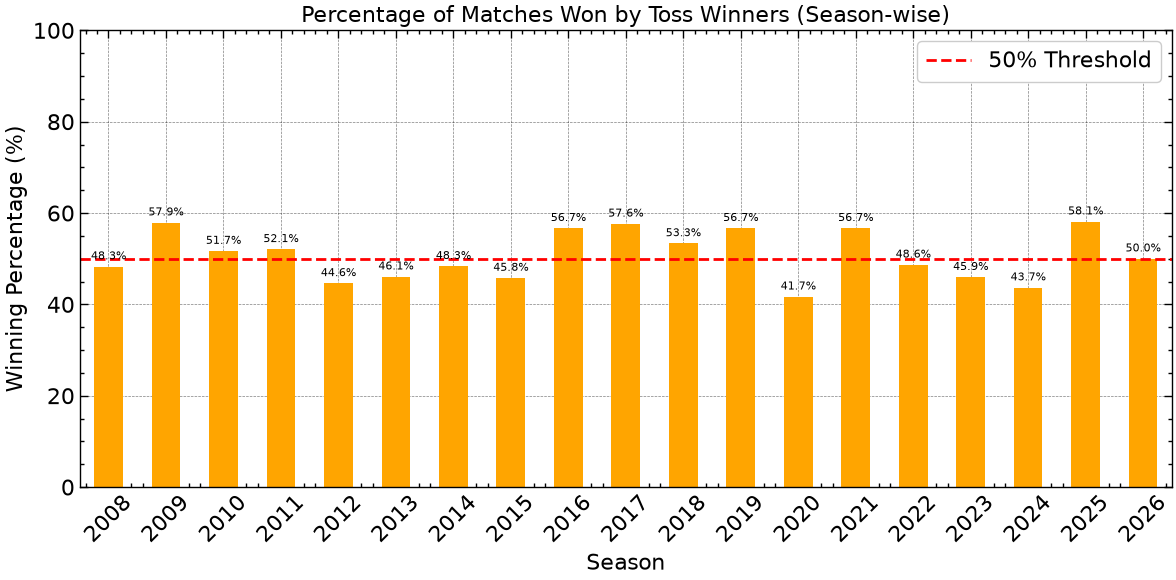

In [36]:
match_df['season'] = pd.to_datetime(match_df['date']).dt.year

match_df['toss_winner_wins'] = (
    match_df['toss_winner'] == match_df['winner']
)

season_stats = (
    match_df.groupby(['season', 'toss_winner_wins'])
    .size()
    .unstack(fill_value=0)
)

season_percentage = (
    season_stats[True] /
    (season_stats[True] + season_stats[False])
) * 100

plt.figure(figsize=(12, 6))

ax = season_percentage.plot(kind='bar', color='orange')

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title('Percentage of Matches Won by Toss Winners (Season-wise)')
plt.ylabel('Winning Percentage (%)')
plt.xlabel('Season')
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.axhline(y=50, color='red', linestyle='--', label='50% Threshold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

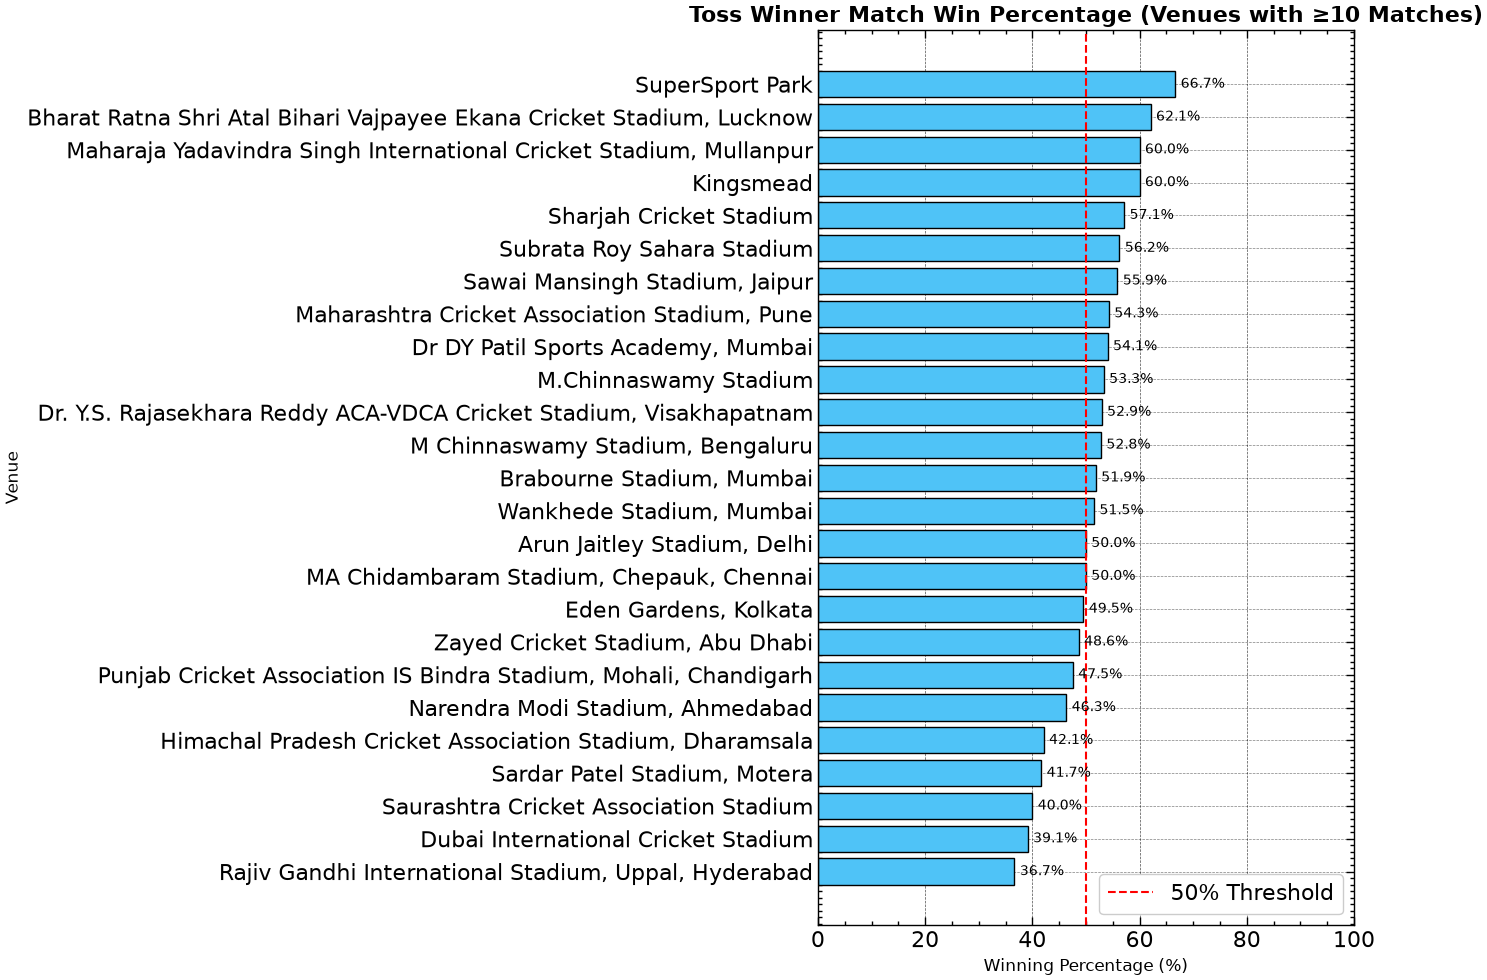

In [24]:
match_df['toss_winner_wins'] = match_df['toss_winner'] == match_df['winner']

venue_stats = match_df.groupby(['venue', 'toss_winner_wins']).size().unstack(fill_value=0)

venue_stats['total_matches'] = venue_stats[True] + venue_stats[False]

filtered_stats = venue_stats[venue_stats['total_matches'] >= 10]

venue_percentage = (filtered_stats[True] / filtered_stats['total_matches']) * 100
venue_percentage = venue_percentage.sort_values(ascending=True)  

plt.figure(figsize=(14, 10))
bars = plt.barh(venue_percentage.index, venue_percentage.values, color='#4FC3F7', edgecolor='black')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.axvline(x=50, color='red', linestyle='--', linewidth=1.5, label='50% Threshold')
plt.title('Toss Winner Match Win Percentage (Venues with ≥10 Matches)', fontsize=16, weight='bold')
plt.xlabel('Winning Percentage (%)', fontsize=12)
plt.ylabel('Venue', fontsize=12)
plt.xlim(0, 100)
plt.legend()

for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2,
             f'{width:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()


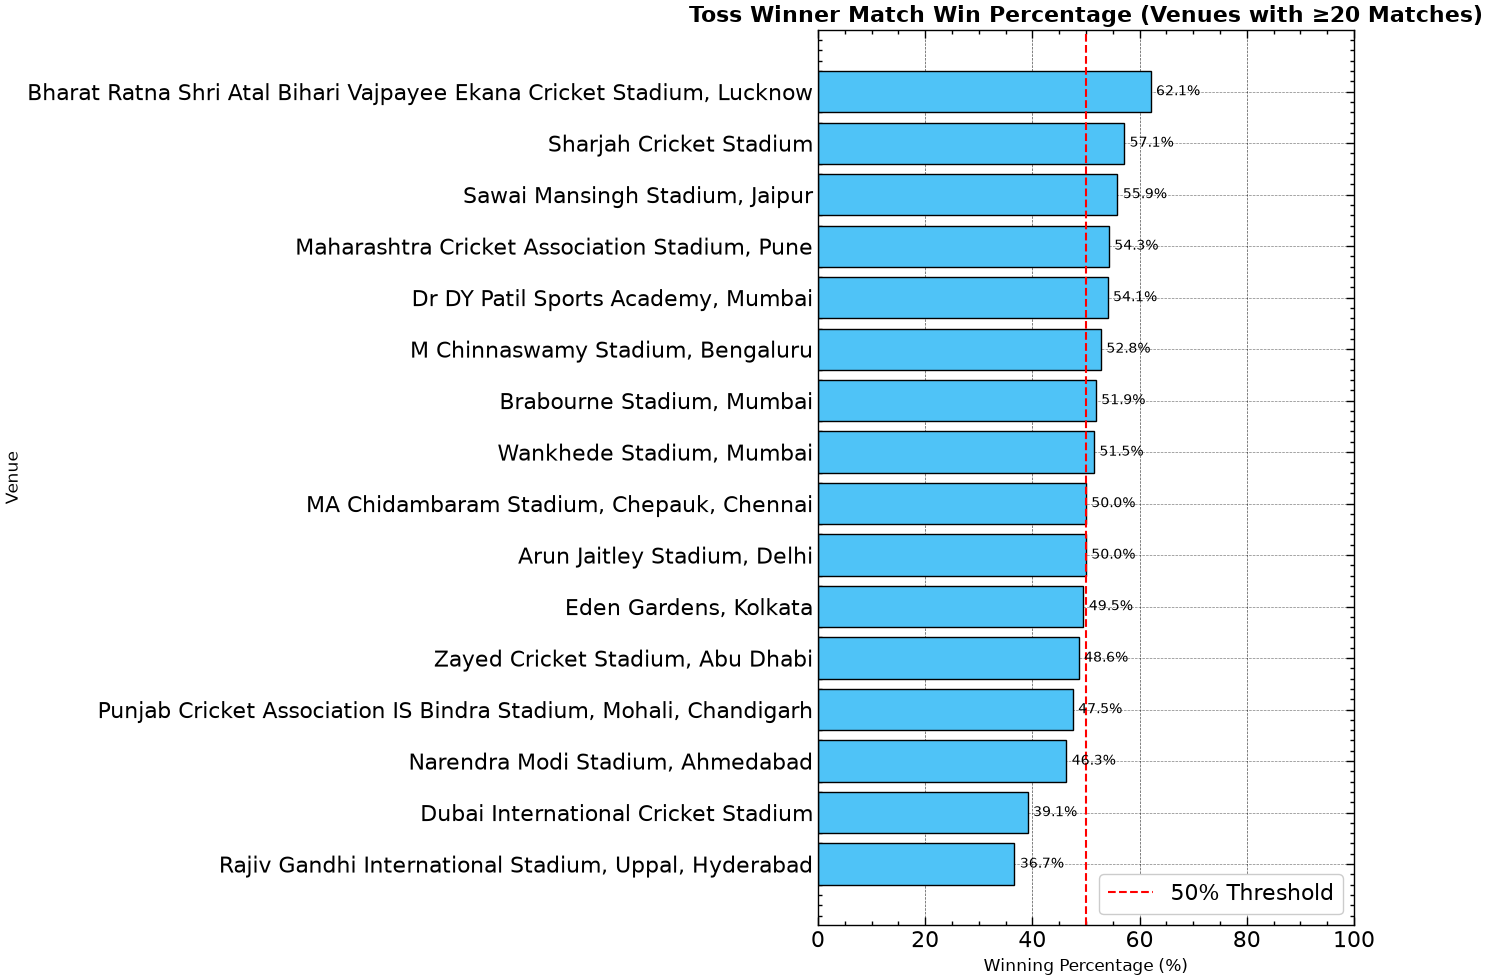

In [25]:
match_df['toss_winner_wins'] = match_df['toss_winner'] == match_df['winner']

venue_stats = match_df.groupby(['venue', 'toss_winner_wins']).size().unstack(fill_value=0)

venue_stats['total_matches'] = venue_stats[True] + venue_stats[False]

filtered_stats = venue_stats[venue_stats['total_matches'] >= 20]

venue_percentage = (filtered_stats[True] / filtered_stats['total_matches']) * 100
venue_percentage = venue_percentage.sort_values(ascending=True) 

plt.figure(figsize=(14, 10))
bars = plt.barh(venue_percentage.index, venue_percentage.values, color='#4FC3F7', edgecolor='black')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.axvline(x=50, color='red', linestyle='--', linewidth=1.5, label='50% Threshold')
plt.title('Toss Winner Match Win Percentage (Venues with ≥20 Matches)', fontsize=16, weight='bold')
plt.xlabel('Winning Percentage (%)', fontsize=12)
plt.ylabel('Venue', fontsize=12)
plt.xlim(0, 100)
plt.legend()

for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2,
             f'{width:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()


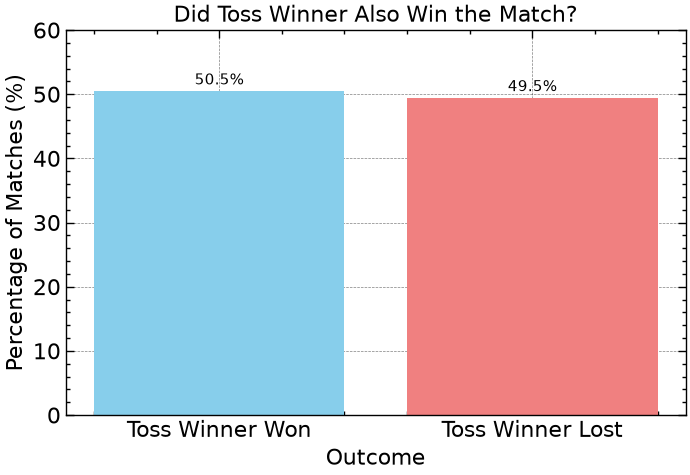

In [29]:
match_df['toss_winner_wins'] = (
    match_df['toss_winner'] == match_df['winner']
)

toss_winner_pct = (
    match_df['toss_winner_wins']
    .value_counts(normalize=True)
    .mul(100)
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    ['Toss Winner Won', 'Toss Winner Lost'],
    [
        toss_winner_pct.get(True, 0),
        toss_winner_pct.get(False, 0)
    ],
    color=['skyblue', 'lightcoral']
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        fontsize=11
    )

plt.title('Did Toss Winner Also Win the Match?')
plt.ylabel('Percentage of Matches (%)')
plt.xlabel('Outcome')
plt.ylim(0, 60)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

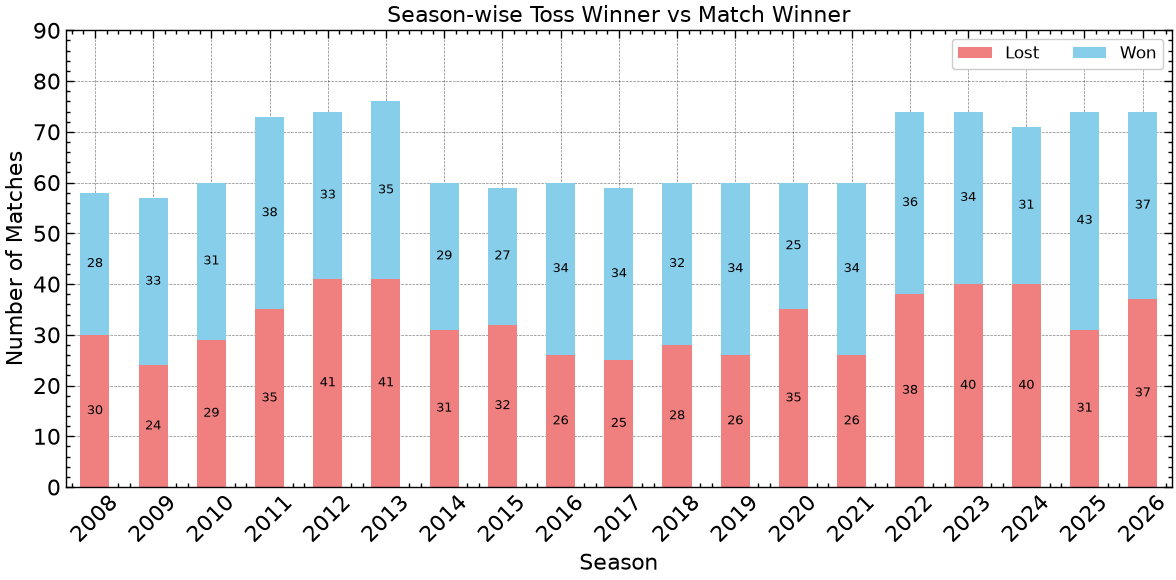

In [57]:
ax = season_stats.plot(
    kind='bar',
    stacked=True,
    color=['lightcoral', 'skyblue'],
    figsize=(12, 6)
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        label_type='center',
        fontsize=9,
        color='black'
    )

plt.title('Season-wise Toss Winner vs Match Winner')
plt.ylabel('Number of Matches')
plt.xlabel('Season')
plt.xticks(rotation=45)
plt.legend(labels=['Lost', 'Won'], loc='upper right', ncol=2, fontsize=12)
plt.ylim(0, 90)
plt.tight_layout()
plt.show()

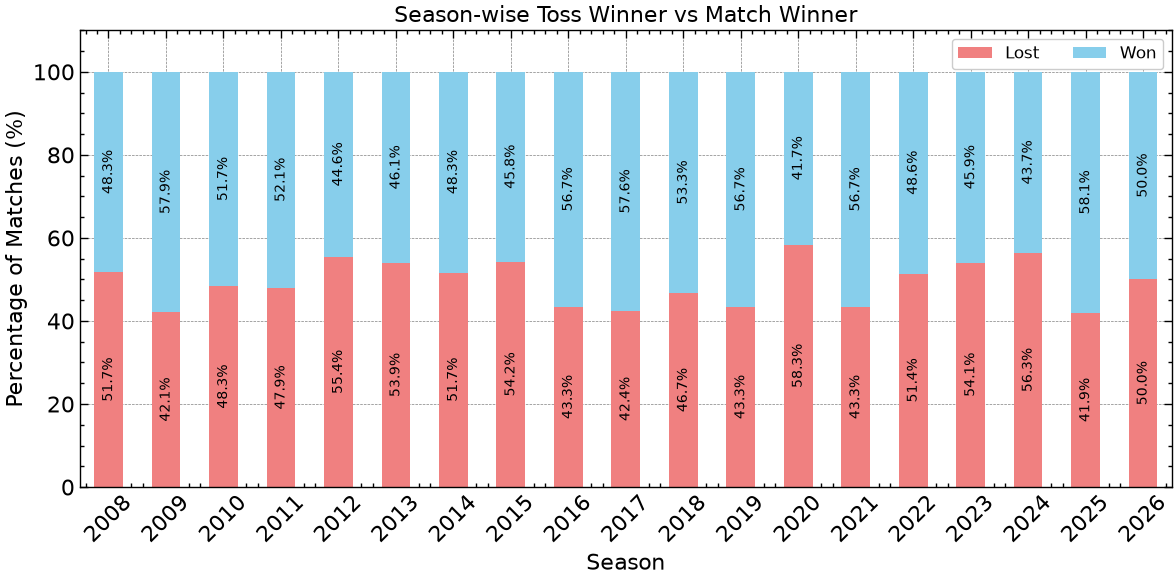

In [70]:
match_df['season'] = pd.to_datetime(match_df['date']).dt.year

match_df['toss_winner_wins'] = (
    match_df['toss_winner'] == match_df['winner']
)

season_stats = (
    match_df.groupby(['season', 'toss_winner_wins'])
    .size()
    .unstack(fill_value=0)
)

season_pct = season_stats.div(season_stats.sum(axis=1), axis=0) * 100

ax = season_pct.plot(
    kind='bar',
    stacked=True,
    color=['lightcoral', 'skyblue'],
    figsize=(12, 6)
)

for container in ax.containers:
    labels = [
        f'{v:.1f}%' if v >= 5 else '' 
        for v in container.datavalues
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type='center',
        fontsize=10,
        rotation = 90
    )

ax.set_title('Season-wise Toss Winner vs Match Winner')
ax.set_ylabel('Percentage of Matches (%)')
ax.set_xlabel('Season')
ax.set_ylim(0, 110)
ax.set_yticks(np.arange(0, 101, 20))
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.legend(['Lost', 'Won'], loc='upper right', fontsize = 12, ncol=2)

plt.tight_layout()
plt.show()

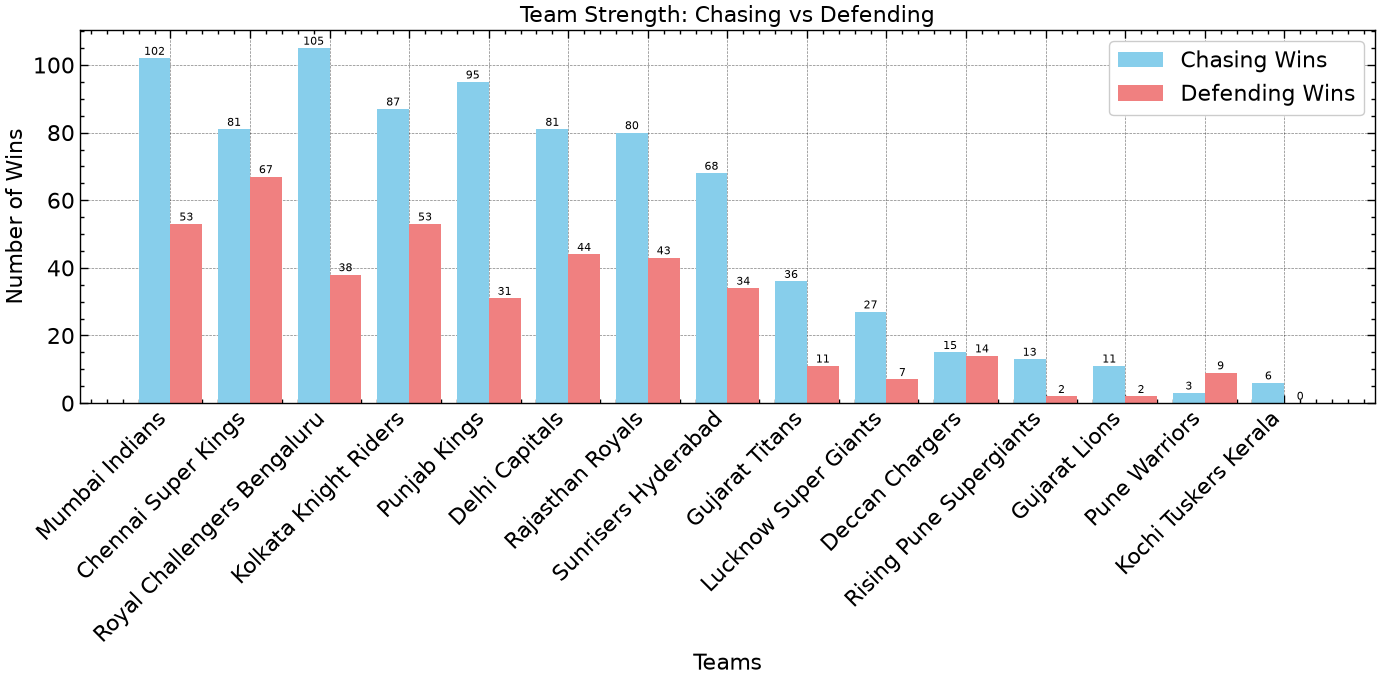

In [19]:
chasing_stats = match_df[match_df['toss_decision'] == 'field']['winner'].value_counts()
defending_stats = match_df[match_df['toss_decision'] == 'bat']['winner'].value_counts()

win_df = pd.DataFrame({
    'Chasing Wins': chasing_stats,
    'Defending Wins': defending_stats
}).fillna(0)

win_df['Total'] = win_df['Chasing Wins'] + win_df['Defending Wins']
win_df = win_df.sort_values('Total', ascending=False)

plt.figure(figsize=(14, 7))
bar_width = 0.4
teams = win_df.index
x = np.arange(len(teams))

plt.bar(x - bar_width/2, win_df['Chasing Wins'], width=bar_width, color='skyblue', label='Chasing Wins')
plt.bar(x + bar_width/2, win_df['Defending Wins'], width=bar_width, color='lightcoral', label='Defending Wins')

for i in range(len(teams)):
    plt.text(x[i] - bar_width/2, win_df['Chasing Wins'].iloc[i] + 1, int(win_df['Chasing Wins'].iloc[i]), ha='center', fontsize=8)
    plt.text(x[i] + bar_width/2, win_df['Defending Wins'].iloc[i] + 1, int(win_df['Defending Wins'].iloc[i]), ha='center', fontsize=8)

plt.xticks(x, teams, rotation=45, ha='right')
plt.ylabel('Number of Wins')
plt.xlabel('Teams')
plt.title('Team Strength: Chasing vs Defending')
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


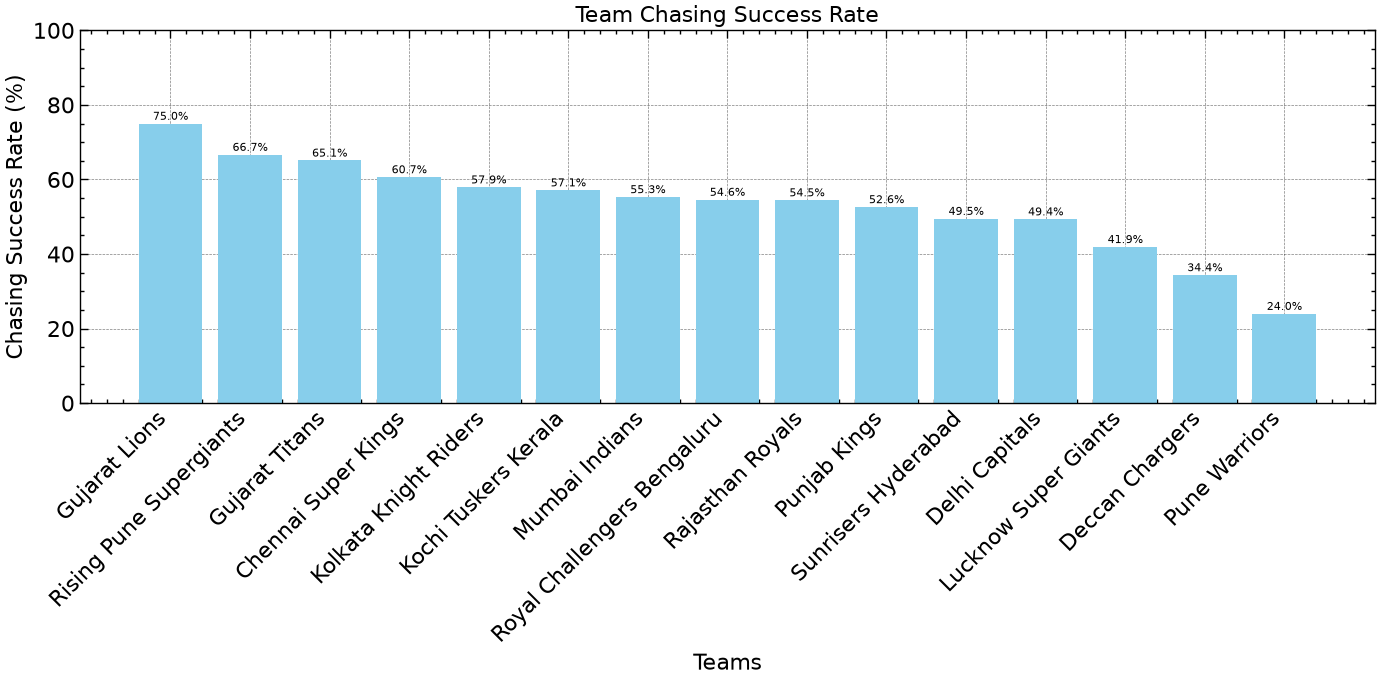

In [21]:
def get_chasing_team(row):
    if row['toss_decision'] == 'field':
        return row['toss_winner']
    else:
        return row['team1'] if row['toss_winner'] != row['team1'] else row['team2']

match_df['chasing_team'] = match_df.apply(get_chasing_team, axis=1)

chasing_matches = match_df['chasing_team'].value_counts()

chasing_wins = match_df[match_df['winner'] == match_df['chasing_team']]['winner'].value_counts()

chasing_df = pd.DataFrame({
    'Chasing Matches': chasing_matches,
    'Chasing Wins': chasing_wins
}).fillna(0)

chasing_df['Chasing Success %'] = (
    chasing_df['Chasing Wins'] / chasing_df['Chasing Matches']
) * 100

chasing_df = chasing_df.sort_values('Chasing Success %', ascending=False)

plt.figure(figsize=(14,7))
x = np.arange(len(chasing_df))

plt.bar(x, chasing_df['Chasing Success %'], color='skyblue')

for i, val in enumerate(chasing_df['Chasing Success %']):
    plt.text(x[i], val + 1, f'{val:.1f}%', ha='center', fontsize=8)

plt.xticks(x, chasing_df.index, rotation=45, ha='right')
plt.ylabel('Chasing Success Rate (%)')
plt.xlabel('Teams')
plt.title('Team Chasing Success Rate')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

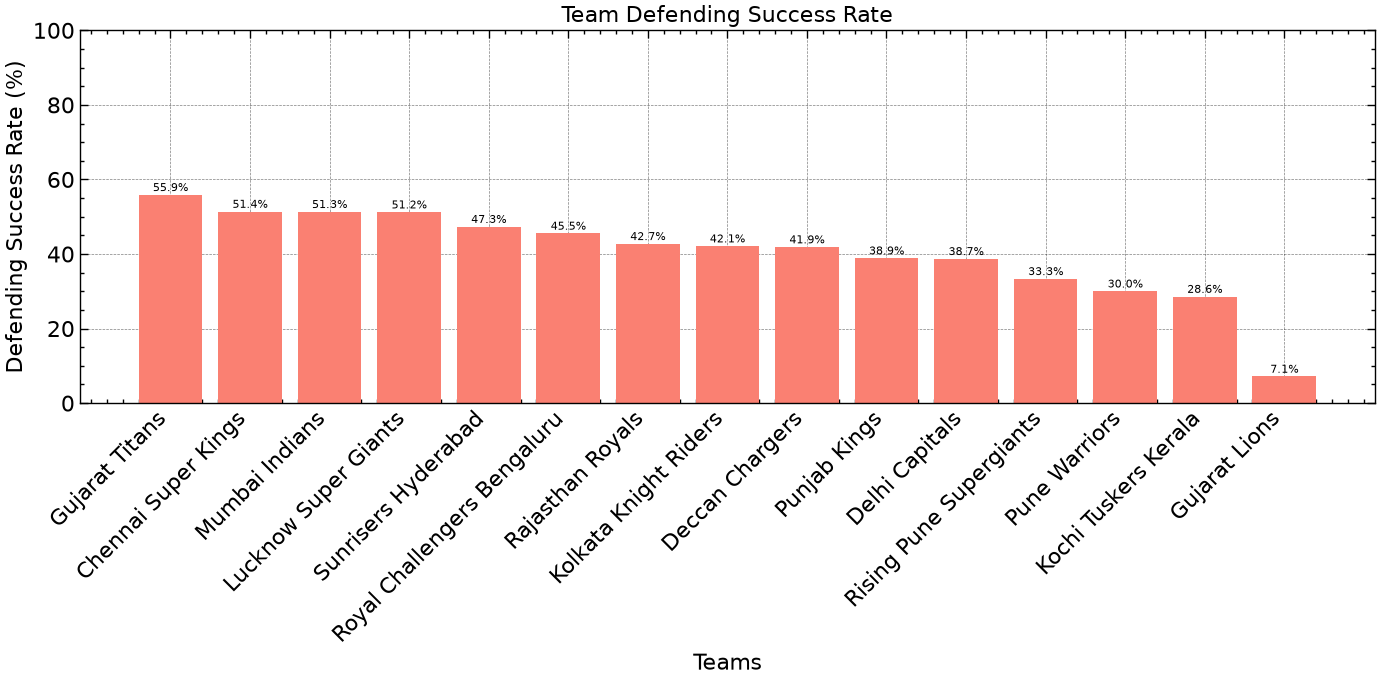

In [22]:
def get_defending_team(row):
    if row['toss_decision'] == 'bat':
        return row['toss_winner']
    else:
        return row['team1'] if row['toss_winner'] != row['team1'] else row['team2']

match_df['defending_team'] = match_df.apply(get_defending_team, axis=1)

defending_matches = match_df['defending_team'].value_counts()

defending_wins = match_df[
    match_df['winner'] == match_df['defending_team']
]['winner'].value_counts()

defending_df = pd.DataFrame({
    'Defending Matches': defending_matches,
    'Defending Wins': defending_wins
}).fillna(0)

defending_df['Defending Success %'] = (
    defending_df['Defending Wins'] / defending_df['Defending Matches']
) * 100

defending_df = defending_df.sort_values('Defending Success %', ascending=False)

plt.figure(figsize=(14, 7))
x = np.arange(len(defending_df))

plt.bar(x, defending_df['Defending Success %'], color='salmon')

for i, val in enumerate(defending_df['Defending Success %']):
    plt.text(x[i], val + 1, f'{val:.1f}%', ha='center', fontsize=8)

plt.xticks(x, defending_df.index, rotation=45, ha='right')
plt.ylabel('Defending Success Rate (%)')
plt.xlabel('Teams')
plt.title('Team Defending Success Rate')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()